In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:16pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="6" color="red">ch10. N차원 배열다루기</font>
 - N차원 배열 객체: 동일 자료형의 집합
 - 2차원 배열은 행렬개념으로 이해
 - [numpy](https://numpy.org/)
 - [numpy API doc](https://numpy.org/doc/stable/reference/index.html)
 # 1장. 넘파이 패키지

In [2]:
import numpy as np
np.__version__ #tensorflow==2.10과 맞는 numpy 버전


'1.23.5'

In [5]:
#np.arange(from,stop,by) : from 부터 stop앞까지 by씩 증가하는 1차원 정수 배열
a = np.arange(15)
print(a.shape) #차원  15열짜리 1차원배열
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [4]:
list(range(15))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

## 1.1 배열속성

In [21]:
from numpy import arange
a = arange(15,dtype=np.int32).reshape(3,5)
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [7]:
type(a) #a변수의 타입

numpy.ndarray

In [12]:
a.dtype #a배열의 요소(item)들의 type   #int32   int  32비트 차지

dtype('int32')

In [22]:
a.dtype.name

'int32'

In [23]:
a.itemsize #한 요소(item)의 bytesize   8bit = 1byte로 

4

In [25]:
a.ndim #축수(차원수)

2

In [26]:
a.size #배열 요소의 갯수

15

In [15]:
a.shape  #배열구조(1차원 15열)

(3, 5)

In [29]:
print('shape 조정전 a:\n',a)
a.shape = (5,3)
print('shape 조정후 a:\n',a)

shape 조정전 a:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
shape 조정후 a:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


In [30]:
a.reshape(3,5)

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [31]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

## 1.2 배열 타입 변경

In [34]:
#배열 요소의 타입변경(x)
a = np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [36]:
a.size # 요소갯수

12

In [39]:
a.dtype #32bit씩 읽겠다 (4byte씩)

dtype('int32')

In [40]:
a.itemsize

4

In [42]:
a.dtype=np.int64   ## 이렇게 type 변경하면 요소값이 변하게 된다!!! 
a.dtype

dtype('int64')

In [43]:
a.itemsize

8

In [44]:
a

array([[ 4294967296, 12884901890],
       [21474836484, 30064771078],
       [38654705672, 47244640266]], dtype=int64)

In [45]:
a.size

6

In [47]:
#배열 요소의 타입변경(o)
a=arange(15).reshape(5,3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [49]:
a.astype(np.int64)  # 값이 리턴되는건 a값을 변경한건 아니다
                        # 출력o -> ark 바뀌지 않음. 출력x ->a바뀜

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [51]:
a.dtype

dtype('int32')

In [52]:
a=a.astype(np.int64) # a에 할당하면 a값이 변경이된다!

In [53]:
a.dtype

dtype('int64')

In [54]:
a.itemsize

8

In [55]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [56]:
a. ravel() #flaten된 배열 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

In [57]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

## 1.3 배열 저장
- pkl(객체, 배열, 머신러닝 모델 저장) vs npy(넘파이 전용포맷, io개선)

In [58]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [65]:
# import time
# start = time.time()
# import pickle
# with open('data/ch10_pkl','wb') as f : 
#     pickle.dump(a,f)
# end =time.time()
# print('실행시간은 :',end-start)

실행시간은 : 0.007020473480224609


In [73]:
%%time
import pickle
with open('data/ch10.pkl','wb') as f : 
    pickle.dump(a,f)

CPU times: total: 0 ns
Wall time: 961 µs


In [72]:
%%time
with open('data/ch10_pkl','rb') as f :
    loaded_a= pickle.load(f)

CPU times: total: 0 ns
Wall time: 0 ns


In [71]:
# a==(파일저장)==> 피클파일(269B) ==>(load)==>loaded_a
loaded_a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [74]:
%%time
np.save('data/ch11.npy',a) #넘파이전용포맷. 빠르고 효율적 안전

CPU times: total: 0 ns
Wall time: 1.44 ms


In [75]:
%%time
loaded_a2=np.load('data/ch11.npy')

CPU times: total: 0 ns
Wall time: 995 µs


In [76]:
# a ==(저장) ==>npy(248B) ==(load)==> loaded_a2
loaded_a2

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

# 2장. 넘파이배열
- array()함수를 이용한 다른 파이썬 데이터구조(list, tup)를 배열변환
- 특정값을 갖는 배열 생성함수 : arange, ones, zeros, full, empty.......
- 랜덤값을 갖는 배열 생성함수 : ....
- [넘파이함수들](https://numpy.org/doc/stable/reference/index.html)
## 2.1 array()함수로 넘파이 배열 만들기
- array(obj, dtype=np.type, copy=T/F)
- array(obj. dtype='type', copy=T/F) type 예 : int16, int32, float16, float32, float64,...

In [78]:
a=np.array([2, 14, 6])   #기본으로 dtype=np.int32  실수의 기본타입은 float64
a

array([ 2, 14,  6])

In [81]:
a[0],a[1],a[2]

(2, 14, 6)

In [82]:
for item in a : 
    print(item, end='\t')

2	14	6	

In [89]:
b=np.array([[1.5,2.3],[4,5]])  #동일자료형의 집합으로 배열 생성 : 정수>실수>문자
                                # 실수 배열의 기본타입 : float64
b.dtype

dtype('float64')

In [91]:
l=[[1.5,2.3],[4,5]]    ## 2차원리스트 인덱싱
l[0][1]

2.3

In [92]:
b[0,1] #2차원 [axis0=행,axis1=열] cf. 1차원[axis0=열]



2.3

In [95]:
a= np.array([[1.5, 2.3],
            [4,5]],dtype=np.float32).reshape(1,4)   #   dtype=np.float32  또는 dtype='float32' 
a
#a=a.astype(np.int64)

array([[1.5, 2.3, 4. , 5. ]], dtype=float32)

In [94]:
a.dtype

dtype('float32')

In [97]:
#a의 배열 구조 변경
a.shape=(2,2)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [ ]:
# a의 dtype(요소의 타입)변경

In [99]:
a=a.astype(np.float16)

In [100]:
a.dtype

dtype('float16')

In [107]:
l = [[1.5, 2.3],[4,5]]
for row in l:
    for item in row:
        print(item, end=" ")

1.5 2.3 4 5 

In [118]:
for i, row in enumerate(a):
    for j, item in enumerate(row):
#         print(f"{i}행{j}열 : {l[i][j]}", end='\t') #float16은 소숫점이하가 불안정
          print(f"{i}행{j}열 : {a[i,j]}", end='\t')
    print()

0행0열 : 1.5	0행1열 : 2.30078125	
1행0열 : 4.0	1행1열 : 5.0	


In [122]:
# 인덱싱
print(b[0,0]) #인덱싱
# print(b[0,2]) # 없는 인덱싱은 에러

SyntaxError: invalid syntax (2712534814.py, line 3)

In [125]:
#슬라이싱 from : stop : by : from부터 stop전까지 by씩 전진. 인덱싱은 음수도 가능
b[0:,1:10] #0~끝행, 1열부터 10열까지 슬라이싱(행과 열 모두 슬라이싱 2차원 배열)

array([[2.3],
       [5. ]])

In [126]:
b[0,1:3]    #0행,1열부터3열전까지(열만 슬라이싱 1차원 배열)

array([2.3])

In [127]:
b[0:1,1:3]

array([[2.3]])

In [145]:
b=np.array([[1,2,3],[6,7,8]])


#모든행의 마지막 열만 추출
b[:,-1:]

array([[3],
       [8]])

In [ ]:
#모든행의 마지막 열만 제외한부분추출

In [146]:
b[:,:-1]

array([[1, 2],
       [6, 7]])

In [156]:
#스칼라 변수
a=10 
b=a
print("a={},b={}, a주소={},b주소={}".format(a,b,id(a),id(b)))
b=-1
print("a={},b={}, a주소={},b주소={}변경후".format(a,b,id(a),id(b)))

a=10,b=10, a주소=1241064538640,b주소=1241064538640
a=10,b=-1, a주소=1241064538640,b주소=1241064538288변경후


In [172]:
#numpy 배열
c=np.array([[1,2],[3,4]],dtype=np.uint8) # 원본 
#d = np.array(c, copy=False) #d=c 동일 할당
d = np.array(c, copy=True) #d=c.copy와 동일 #깊은 복사
#d = c.copy() #할당
print("c=",c,sep="\n")
print("d=",d,sep="\n")
print('두 변수의 주소:', id(c),id(d))
d[0,0]=9

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소: 1241205403024 1241205403504


In [170]:
print("c=",c,sep="\n")
print("d=",d,sep="\n")
print('두 변수의 주소:', id(c),id(d))

c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소: 1241205406000 1241205397744


In [ ]:
#copy=False해도 깊은 복사가 되는 경우 : dtype이 바뀌면 자동 깊은 복사
c=np.array([[1,2],[3,4]],dtype=np.uint8) # 원본 
d = np.array(c, copy=False, dtype=np.uint16)
print("c=",c,sep="\n")
print("d=",d,sep="\n")
print('두 변수의 주소:', id(c),id(d))
d[0,0]=9

## 2.2 기본값이 있는 배열 만들기
- np.zeros( tup, [dtype] ) : 요소들이 다 0.0
- np.ones(tup, [dtype] ) : 요소들이 다 1.0
- np.full(tup, 기본값) : 요소들이 다 두번째 매개변수인 기본값
- np.empty(tup) : 초기 내용은 임의의 값인 배열(메모리 상태에 따라 달라짐)

※ 위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64, dtype속성을 따로 지정할 수 있음


In [232]:
np.zeros((3,5),dtype=np.int32)  #3행5열짜리 2차원 float64 배열(요소들은 다 0)
np.zeros((5,))#5열짜리 1차원 float64 배열(요소들은 다 0)
np.zeros(5)

array([0., 0., 0., 0., 0.])

In [235]:
x = np.zeros((2,5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[False False False False False]
 [False False False False False]]
bool
1


In [238]:
np.ones((3,5),dtype=np.int32)  #3행5열짜리 2차원 float64 배열(요소들은 다 1)
np.ones((5,))#5열짜리 1차원 float64 배열(요소들은 다 1)
np.ones(5)

array([1., 1., 1., 1., 1.])

In [239]:
x = np.ones((2,5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[ True  True  True  True  True]
 [ True  True  True  True  True]]
bool
1


In [241]:
x= np.full((2,5),255.0)
print(x)
print(x.dtype)

[[255. 255. 255. 255. 255.]
 [255. 255. 255. 255. 255.]]
float64


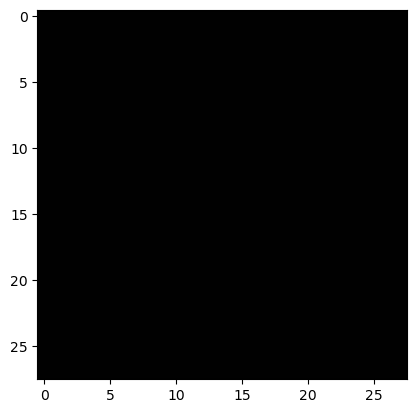

In [274]:
import matplotlib.pyplot as plt
img = np.full((28,28),200,dtype=np.uint8)
img = np.full((28,28),100,dtype=np.uint8)
img = np.zeros((28,28),dtype=np.uint8)
img = np.ones((28,28),dtype=np.uint8)
plt.imshow(img, cmap='gray',vmin=0,vmax=255)
#plt.axis('off')
plt.show()


In [273]:
np.empty((3,2))

array([[0.37472222, 0.33722222],
       [0.37472222, 4.03322222],
       [4.07072222, 0.33722222]])

## 2.3 랜덤값을 갖는 배열 만들기
- np.random.random( tup ) : 0부터 1 미만의 균등 분포를 갖는 tup shape 사이즈 랜덤값
- np.random.uinform(low=0, high=1.0, size=tup) : low부터 high 미만까지 균등분포를 갖는 랜덤값
- np.random.normal(loc=0.0, scale=1.0, size=tup) : 평균 loc, 표준편차scale을 갖는 정규분포 랜덤값
   ↑ n차원 배열   ↓1차원배열
- np.random.rand(n) : 균등분포의 1차원 0~1미만 난수 배열 발생(난수가 n개)
- np.random.randn(n) :  표준정규분포(평균0, 표준편차가 1인 정규분포)의 1차원 난수 배열 발생(난수 n 개)

- np.random.randint(n) : 0부터 n미만의 정수 난수 1개발생 == random.randint(0,n-1)
- np.random.randint(from,to) : from 부터 to 미만의 정수 난수 1개 발생 == random.ranint(from, to-1)

In [303]:
np.random.random((2,3))

array([[0.7165162 , 0.00888643, 0.41729944],
       [0.64725212, 0.29791897, 0.23736275]])

In [304]:
np.random.rand(100000)

array([0.78251493, 0.55948619, 0.45843703, ..., 0.68263518, 0.09888834,
       0.20618118])

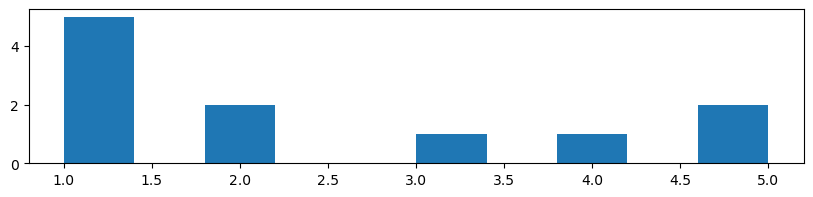

In [310]:
plt.figure(figsize=(10,2)) # 그래프 사이즈 조절
x = [1, 2, 3, 1, 1, 1, 2 ,1, 4, 5, 5] 
plt.hist(x, bins=10)
plt.show()

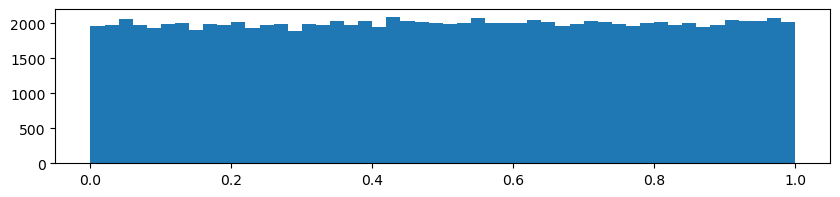

In [326]:
plt.figure(figsize=(10,2)) # 그래프 사이즈 조절
#x = np.random.random(100000)
#x = np.random.uniform(1,10, 100000)
x = np.random.rand(100000)
plt.hist(x, bins=50)
plt.show()

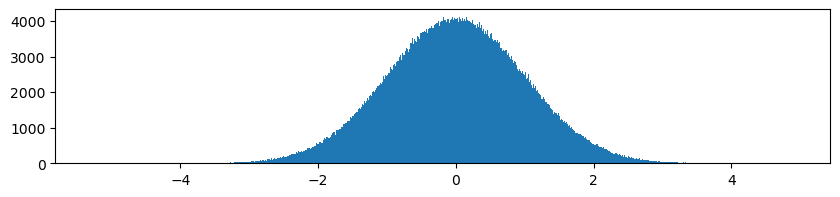

In [337]:
plt.figure(figsize=(10,2)) # 그래프 사이즈 조절
#x = np.random.random(100000)     
#x = np.random.uniform(1,10, 100000)
x = np.random.normal(50,10,1000000)     # 정규분포
x = np.random.normal(0,1,1000000)     # 정규분포
x = np.random.randn(1000000)#표준정규분포  
plt.hist(x, bins=1000)
plt.show()

# 4장. 복사와 뷰
## 4.1 할당

In [175]:
#스칼라 변수
a= 10
b=a
print('a와b주소:',id(a),id(b))
b=99
print('수정 후 a와b주소:',id(a),id(b))
print('수정 후 a와b데이터 :',a,b)

a와b주소: 1241064538640 1241064538640
수정 후 a와b주소: 1241064538640 1241064541488
수정 후 a와b데이터 : 10 99


In [177]:
# 배열 
a= np.arange(12)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [179]:
b=a
#b=np.array(a, copy=False) 와 같음
a.shape, type(a), a.ndim, id(a)

((12,), numpy.ndarray, 1, 1241205403312)

In [180]:
b.shape, type(b), b.ndim, id(b)

((12,), numpy.ndarray, 1, 1241205403312)

In [181]:
a is b

True

In [186]:
a == b

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [188]:
np.all(a==b) #np.all() : array배열 안의 모든 값이 True인지 여부

True

In [189]:
b.shape =(3,4)

In [191]:
b.shape, type(b), b.ndim, id(b)

((3, 4), numpy.ndarray, 2, 1241205403312)

In [192]:
a.shape, type(a), a.ndim, id(a)

((3, 4), numpy.ndarray, 2, 1241205403312)

## 4.2 뷰(View) : 얕은 복사

In [193]:
a=np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [194]:
c = a.view() #얕은 복사
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [195]:
id(a),id(c)

(1241205405712, 1241205405808)

In [196]:
a==c

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [199]:
np.all(a==c)

True

In [198]:
c is a

False

In [200]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [202]:
c.shape=(2,6)

In [203]:
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [204]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [207]:
# 배열 복사본 c의 특정 요소만 변경
c[1,::2]=-99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

In [208]:
a

array([[  0,   1,   2,   3],
       [  4,   5, -99,   7],
       [-99,   9, -99,  11]])

In [214]:
#슬라이싱이 될 때 뷰가 반환됨(shape과 dtype 변경외에는 원본도 변경)
a=np.array([[99, 88, 77, 85],
           [95, 79, 73, 66],
           [99, 98, 97, 95],])
X=a[:,:-1]
#Y=a[:,-1:]
X

array([[99, 88, 77],
       [95, 79, 73],
       [99, 98, 97]])

In [219]:
X=a[:,:-1].copy()
X

array([[99, 88,  1],
       [95, 79,  1],
       [99, 98, -1]])

In [220]:
X[0:2,-1] =1
X[-1,-1]= -1
X

array([[99, 88,  1],
       [95, 79,  1],
       [99, 98, -1]])

## 4.3 깊은 복사

In [221]:
a=np.array([[99, 88, 77, 85],
           [95, 79, 73, 66],
           [99, 98, 97, 95],])
a

array([[99, 88, 77, 85],
       [95, 79, 73, 66],
       [99, 98, 97, 95]])

In [ ]:
X=a[:,:-1] #얕은 복사(view 생성)
X=a[:,:-1].copy() #깊은 복사
#X=np.array(a[:,:-1],copy=True) #깊은 복사

In [ ]:
X[:,:2]=1

In [222]:
X[-1,-1]=-1
X

array([[99, 88,  1],
       [95, 79,  1],
       [99, 98, -1]])

In [223]:
a

array([[99, 88, 77, 85],
       [95, 79, 73, 66],
       [99, 98, 97, 95]])